# Performance Analytics
This notebook computes daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, Fund Scorecard, Tracking Error, and Benchmark Comparison.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
plt.style.use('ggplot')

## Load datasets
Update paths if required.

In [5]:
nav = pd.read_csv('../data/processed/nav_history_clean.csv')
scheme = pd.read_csv('../data/processed/scheme_performance_clean.csv')
benchmark = pd.read_csv('../data/raw/Bluestock_MF_Datasets/10_benchmark_indices.csv')

nav['date'] = pd.to_datetime(nav['date'])
benchmark['date'] = pd.to_datetime(benchmark['date'])

nav = nav.merge(scheme[['amfi_code','scheme_name']], on='amfi_code', how='left')
nav = nav[nav['scheme_name'].notna()].copy()
print('Missing scheme_name:', nav['scheme_name'].isna().sum())
print(nav.head())
print(scheme.head())
print(benchmark.head())

Missing scheme_name: 0
   amfi_code       date       nav                                scheme_name
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  r

## Daily Returns

In [6]:
print(f"nav shape: {nav.shape}")
print(f"Missing scheme_name: {nav['scheme_name'].isna().sum()}")
nav[['amfi_code', 'scheme_name']].drop_duplicates().head()

nav shape: (46000, 4)
Missing scheme_name: 0


,amfi_code,scheme_name
0,100016,HDFC Top 100 Fund - Regular Plan - Growth
1150,100025,HDFC Short Term Debt Fund - Regular - Growth
2300,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3450,101206,ABSL Frontline Equity Fund - Regular - Growth
4600,101207,ABSL Small Cap Fund - Regular - Growth


In [7]:
if 'scheme_name' not in nav.columns:
    nav = nav.merge(scheme[['amfi_code','scheme_name']], on='amfi_code', how='left')

group_col = 'scheme_name' if 'scheme_name' in nav.columns else 'amfi_code'
nav = nav.sort_values([group_col,'date'])
nav['daily_return'] = nav.groupby(group_col)['nav'].pct_change()

nav[[group_col,'date','daily_return']].head()

,scheme_name,date,daily_return
3450,ABSL Frontline Equity Fund - Regular - Growth,2022-01-03,NaN
3451,ABSL Frontline Equity Fund - Regular - Growth,2022-01-04,0.001153
3452,ABSL Frontline Equity Fund - Regular - Growth,2022-01-05,0.003866
3453,ABSL Frontline Equity Fund - Regular - Growth,2022-01-06,-0.002128
3454,ABSL Frontline Equity Fund - Regular - Growth,2022-01-07,-0.006314


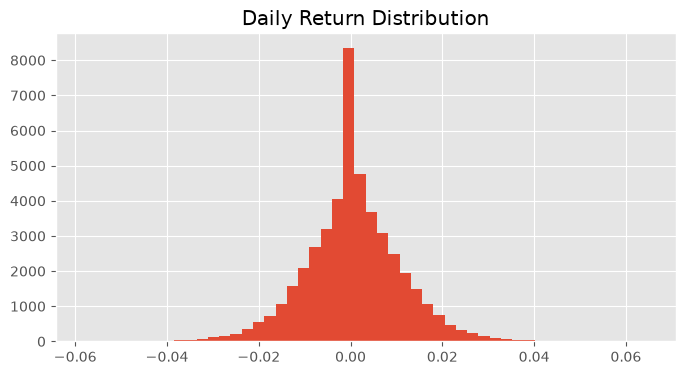

In [8]:
nav['daily_return'].hist(bins=50,figsize=(8,4))
plt.title('Daily Return Distribution')
plt.show()

## CAGR

In [9]:
def cagr(start,end,years):
    return (end/start)**(1/years)-1

cagr_results=[]
for scheme_name,g in nav.groupby('scheme_name'):
    g=g.sort_values('date')
    years=(g['date'].max()-g['date'].min()).days/365.25
    if years>0:
        cagr_results.append([scheme_name,cagr(g['nav'].iloc[0],g['nav'].iloc[-1],years)])
cagr_df=pd.DataFrame(cagr_results,columns=['scheme_name','cagr'])
cagr_df.head()

,scheme_name,cagr
0,ABSL Frontline Equity Fund - Regular - Growth,0.235384
1,ABSL Liquid Fund - Regular - Growth,0.065090
2,ABSL Small Cap Fund - Regular - Growth,0.079388
3,Axis Bluechip Fund - Direct - Growth,0.078976
4,Axis Bluechip Fund - Regular - Growth,0.063680


## Sharpe Ratio

In [11]:
RF=0.065
sharpe=nav.groupby('scheme_name')['daily_return'].agg(['mean','std']).reset_index()
sharpe['sharpe_ratio']=((sharpe['mean']-RF/252)/sharpe['std'])*np.sqrt(252)
sharpe.sort_values('sharpe_ratio',ascending=False).head()

,scheme_name,mean,std,sharpe_ratio
25,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.008941,1.448291
22,Kotak Flexicap Fund - Regular - Growth,0.001082,0.010008,1.306744
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.011134,1.234930
33,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008656,1.208267
18,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.012152,1.180101


## Sortino Ratio

In [13]:
rows=[]
for s,g in nav.groupby('scheme_name'):
    d=g['daily_return'].dropna()
    downside=d[d<0]
    ds=downside.std()
    ratio=((d.mean()-RF/252)/ds)*np.sqrt(252) if ds and not np.isnan(ds) else np.nan
    rows.append([s,ratio])
sortino=pd.DataFrame(rows,columns=['scheme_name','sortino_ratio'])
sortino.head()

,scheme_name,sortino_ratio
0,ABSL Frontline Equity Fund - Regular - Growth,1.799563
1,ABSL Liquid Fund - Regular - Growth,-1.681038
2,ABSL Small Cap Fund - Regular - Growth,0.276644
3,Axis Bluechip Fund - Direct - Growth,0.221087
4,Axis Bluechip Fund - Regular - Growth,0.052574


## Alpha and Beta

In [15]:
bench=benchmark[['date','close_value']].sort_values('date').copy()
bench['bench_return']=bench['close_value'].pct_change()
alpha_beta=[]
for s,g in nav.groupby('scheme_name'):
    m=g[['date','daily_return']].merge(bench[['date','bench_return']],on='date').dropna()
    if len(m)>30:
        r=linregress(m['bench_return'],m['daily_return'])
        alpha_beta.append([s,r.intercept*252,r.slope])
alpha_beta=pd.DataFrame(alpha_beta,columns=['scheme_name','alpha','beta'])
alpha_beta.head()

,scheme_name,alpha,beta
0,ABSL Frontline Equity Fund - Regular - Growth,0.208464,1.062703e-05
1,ABSL Liquid Fund - Regular - Growth,0.061229,-6.172390e-07
2,ABSL Small Cap Fund - Regular - Growth,0.109861,-4.983429e-06
3,Axis Bluechip Fund - Direct - Growth,0.076106,1.206390e-05
4,Axis Bluechip Fund - Regular - Growth,0.072807,-6.036841e-06


## Maximum Drawdown

In [16]:
mdd=[]
for s,g in nav.groupby('scheme_name'):
    g=g.sort_values('date')
    rm=g['nav'].cummax()
    dd=g['nav']/rm-1
    mdd.append([s,dd.min()])
mdd_df=pd.DataFrame(mdd,columns=['scheme_name','max_drawdown'])
mdd_df.head()

,scheme_name,max_drawdown
0,ABSL Frontline Equity Fund - Regular - Growth,-0.112916
1,ABSL Liquid Fund - Regular - Growth,-0.001622
2,ABSL Small Cap Fund - Regular - Growth,-0.354469
3,Axis Bluechip Fund - Direct - Growth,-0.217514
4,Axis Bluechip Fund - Regular - Growth,-0.144016


## Fund Scorecard

In [17]:
score=cagr_df.merge(sharpe[['scheme_name','sharpe_ratio']],on='scheme_name')\
.merge(alpha_beta,on='scheme_name')\
.merge(mdd_df,on='scheme_name')
score['score']=score['cagr'].rank(pct=True)*30+score['sharpe_ratio'].rank(pct=True)*25+score['alpha'].rank(pct=True)*20+(-score['max_drawdown']).rank(pct=True)*25
score=score.sort_values('score',ascending=False)
score.head()

,scheme_name,cagr,sharpe_ratio,alpha,beta,max_drawdown,score
8,DSP Small Cap Fund - Regular - Growth,0.322874,0.949796,0.296003,0.000008,-0.311719,89.125
36,SBI Small Cap Fund - Regular Plan - Growth,0.324235,0.945308,0.295143,0.000013,-0.287060,87.625
18,ICICI Pru Midcap Fund - Regular - Growth,0.328274,1.180101,0.278249,0.000025,-0.181885,86.125
26,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,1.234930,0.295861,-0.000022,-0.163967,84.125
7,DSP Midcap Fund - Regular - Growth,0.295811,1.132122,0.260204,0.000010,-0.172481,76.875


## Save Outputs

In [ ]:
cagr_df.to_csv('../data/processed/cagr_table.csv',index=False)
sharpe.to_csv('../data/processed/sharpe_ratio.csv',index=False)
sortino.to_csv('../data/processed/sortino_ratio.csv',index=False)
alpha_beta.to_csv('../data/processed/alpha_beta.csv',index=False)
mdd_df.to_csv('../data/processed/maximum_drawdown.csv',index=False)
score.to_csv('../data/processed/fund_scorecard.csv',index=False)
print('Outputs saved.')

Outputs saved.
